# 02 · Un proceso gaussiano desde cero, y luego con scikit-learn

**Pregunta de la clase.** Una ciudad pequeña registra su demanda eléctrica diaria (MW).
Tenemos 4 semanas de datos, con un hueco de 3 días en que falló el medidor.
**¿Cuánta capacidad debemos reservar para la próxima semana?**

Para responder no basta una curva: necesitamos la curva **y su margen de error**.
Eso es exactamente lo que da un proceso gaussiano (GP).

Plan (60 min):

1. Los datos y la pregunta
2. El kernel: nuestra hipótesis sobre cómo se parecen dos días
3. El GP *antes* de ver datos (a priori)
4. El GP *después* de ver datos (a posteriori) — las 6 líneas de álgebra
5. La respuesta a la pregunta
6. Lo mismo con scikit-learn en 3 líneas
7. Demostración: ambas rutas dan el mismo resultado
8. Qué queda de tarea

> Cada bloque de código sigue **la misma receta del código MATLAB que vimos en la presentación**,
> con los mismos nombres de variables (`kxx`, `kXX`, `B1`…`B4`, `R`, `A`, `mpost`, `vpost`, `spost`). Así puedes leerlos lado a lado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
AZUL, ORO, GRIS = "#003D79", "#D59F0F", "#8A8F98"   # colores UNAM
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

## 1. Los datos y la pregunta

Usamos datos **sintéticos** (generados con una fórmula) para que todos tengamos la misma serie y podamos
esconder el futuro y luego destaparlo. La serie imita a una ciudad que entra en una ola de calor:
la demanda base sube de ~120 a ~145 MW a lo largo del mes, con un vaivén suave encima y ruido de medición.

In [2]:
def demanda_ciudad(dias=35, semilla=30):
    """Demanda diaria (MW) de una ciudad pequeña durante `dias` días."""
    rng = np.random.default_rng(semilla)
    t = np.arange(dias, dtype=float)                 # día 0, 1, 2, ...
    tendencia = 120 + 25 / (1 + np.exp(-(t - 14) / 4))   # ola de calor: sube 25 MW a media serie
    vaiven    = 5 * np.sin(2 * np.pi * t / 14)           # oscilación suave de ±5 MW
    ruido     = rng.normal(0, 2.5, dias)                 # error de medición
    return t, tendencia + vaiven + ruido

t, y = demanda_ciudad()

# Qué vimos y qué no: 7 días futuros escondidos + 3 días con el medidor descompuesto
observado = np.ones(len(t), dtype=bool)
observado[28:] = False          # días 28..34 = la próxima semana (no la conocemos)
observado[12:15] = False        # días 12, 13, 14 = falla del medidor

X, Y = t[observado], y[observado]      # mayúsculas: los DATOS (como en el código MATLAB)
print(f"{len(X)} días observados, {(~observado).sum()} sin dato")

25 días observados, 10 sin dato


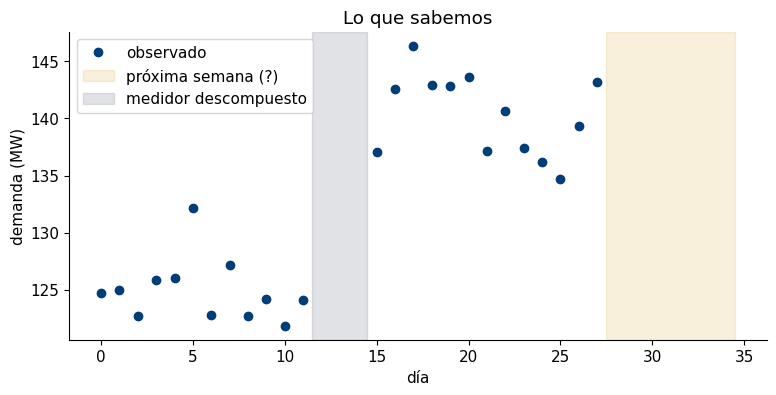

In [3]:
plt.plot(X, Y, "o", color=AZUL, label="observado")
plt.axvspan(27.5, 34.5, color=ORO, alpha=0.15, label="próxima semana (?)")
plt.axvspan(11.5, 14.5, color=GRIS, alpha=0.25, label="medidor descompuesto")
plt.xlabel("día"); plt.ylabel("demanda (MW)"); plt.legend(loc="upper left"); plt.title("Lo que sabemos")
plt.show()

🟡 **Tu turno.** Antes de hacer cuentas: a ojo, ¿cuánta capacidad reservarías para la próxima semana? Anota un número. Al final lo comparamos.

## 2. El kernel: ¿cuánto se parecen dos días?

Un GP no supone una fórmula para la curva. Supone algo más humilde: **qué tan parecidos son dos valores
según qué tan lejos están sus días**. Esa regla es el **kernel**. Hoy usamos uno solo, el más común (RBF o *exponencial cuadrado*):

$$k(t, t') = \sigma_f^2 \, \exp\!\left(-\frac{(t-t')^2}{2\ell^2}\right)$$

- $\ell$ (*length scale*): a cuántos días de distancia dos demandas dejan de parecerse. Hoy: **5 días**.
- $\sigma_f$: cuánto puede subir o bajar la curva en total. Hoy: la desviación estándar de los datos.
- $\sigma_n$: el ruido del medidor. Hoy: **2.5 MW**.

Estos tres números son los **hiperparámetros**. Primero los fijamos a mano; al final scikit-learn los aprenderá solo.

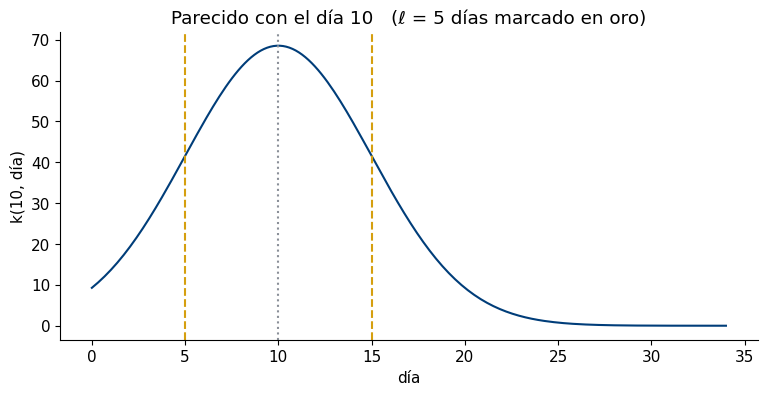

In [4]:
ell   = 5.0          # días
sigma_f = Y.std()    # MW
sigma_n = 2.5        # MW
b     = Y.mean()     # media a priori: sin datos, apostamos al promedio (en MATLAB: b = mean(Y))

def k(a, c):
    """Kernel RBF entre todos los pares de días de `a` y de `c`. Devuelve una matriz len(a) x len(c)."""
    return sigma_f**2 * np.exp(-0.5 * (a[:, None] - c[None, :])**2 / ell**2)

# La curva del kernel: parecido entre el día 10 y cualquier otro
d = np.linspace(0, 34, 200)
plt.plot(d, k(np.array([10.0]), d)[0], color=AZUL)
plt.axvline(10, color=GRIS, ls=":"); plt.axvline(10 + ell, color=ORO, ls="--"); plt.axvline(10 - ell, color=ORO, ls="--")
plt.xlabel("día"); plt.ylabel("k(10, día)"); plt.title(f"Parecido con el día 10   (ℓ = {ell:.0f} días marcado en oro)")
plt.show()

🟡 **Tu turno.** Cambia `ell` a 1 y luego a 15 y vuelve a ejecutar. ¿Qué le pasa a la campana? Vuelve a dejarlo en 5.

## 3. El GP antes de ver datos (a priori)

Con el kernel podemos construir la matriz de parecidos entre **todos** los días de la malla donde queremos predecir:
$k_{xx}$. A partir de ella podemos *sortear* curvas posibles: eso es lo que el GP cree **antes** de mirar un solo dato.

En MATLAB:
```matlab
n = 100; x = linspace(-6,6,n)';
kxx = phix * Sigma * phix';                                  % kxx
s   = bsxfun(@plus, m, chol(kxx + 1e-8*eye(n))' * randn(n,funct));
stdpi = sqrt(diag(kxx));
```

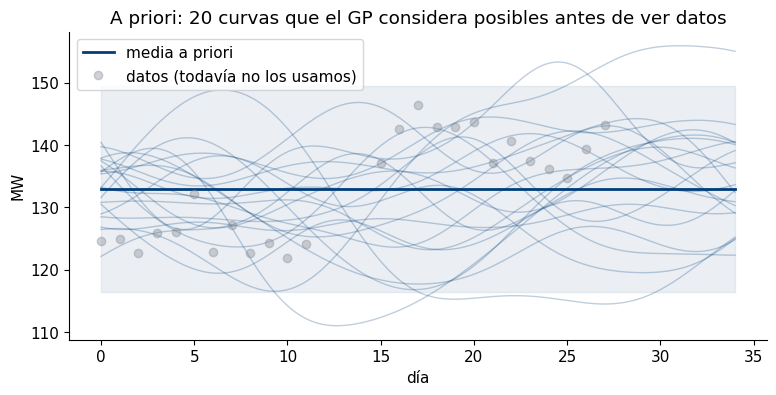

In [5]:
n = 200
x = np.linspace(0, 34, n)                 # minúscula: la malla donde PREDECIMOS (como en MATLAB)
funct = 20                                # cuántas curvas sortear

m   = np.full(n, b)                       # media a priori
kxx = k(x, x)                             # matriz n x n de parecidos          (MATLAB: kxx)
L   = np.linalg.cholesky(kxx + 1e-8 * np.eye(n))     # "raíz cuadrada" de la matriz (MATLAB: chol(...)')
s   = m[:, None] + L @ np.random.default_rng(1).normal(size=(n, funct))    # 20 curvas a priori
stdpi = np.sqrt(np.diag(kxx))             # desviación a priori en cada día

plt.plot(x, s, color=AZUL, alpha=0.25, lw=1)
plt.fill_between(x, m - 2*stdpi, m + 2*stdpi, color=AZUL, alpha=0.08)
plt.plot(x, m, color=AZUL, lw=2, label="media a priori")
plt.plot(X, Y, "o", color=GRIS, alpha=0.4, label="datos (todavía no los usamos)")
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left")
plt.title("A priori: 20 curvas que el GP considera posibles antes de ver datos")
plt.show()

Lo que ves: curvas suaves (porque $\ell = 5$), que suben y bajan alrededor del promedio con amplitud $\sigma_f$.
Ninguna pasa por los datos porque **todavía no se los hemos enseñado**.

🟡 **Tu turno.** ¿Qué es `np.diag(kxx)`? Imprímelo. ¿Por qué todos sus elementos valen lo mismo?

## 4. El GP después de ver datos (a posteriori)

Aquí está el corazón del método. Son **seis líneas**. Las escribimos con los mismos nombres del código MATLAB:

```matlab
B1 = phix * mu;                  % media a priori en la malla
B2 = phix * Sigma * phiX';       % kxX : parecido entre malla y datos
B3 = kXX + sigma^2 * eye(N);     % G   : parecido entre datos, más el ruido del medidor
R  = chol(B3);
B4 = Y' - M;                     % datos menos la media
A  = B2 / R;
mpost = B1 + A * (R' \ B4);       % media a posteriori
vpost = kxx - A * A';            % covarianza a posteriori
```

En palabras:
- **B2** dice a qué datos se parece cada día de la malla.
- **B3** dice cuánto se parecen los datos entre sí (y cuánto ruido traen).
- **A** combina las dos: cuánto "pesa" cada dato para cada día de la malla.
- **mpost** = media a priori + (pesos × cuánto se desviaron los datos de la media).
- **vpost** = incertidumbre a priori **menos** lo que los datos nos enseñaron. Los datos solo pueden *restar* incertidumbre.

In [6]:
N   = len(X)
kXX = k(X, X)                                   # parecidos entre los datos         (MATLAB: kXX)

B1 = np.full(n, b)                              # media a priori en la malla        (MATLAB: B1 = phix*mu)
B2 = k(x, X)                                    # kxX: malla vs datos               (MATLAB: B2)
B3 = kXX + sigma_n**2 * np.eye(N)               # G: datos vs datos + ruido         (MATLAB: B3)
R  = np.linalg.cholesky(B3).T                   # MATLAB chol() devuelve la triangular SUPERIOR; NumPy la inferior → .T
M  = np.full(N, b)                              # media a priori en los datos       (MATLAB: M = phiX*mu)
B4 = Y - M                                      # cuánto se desviaron los datos     (MATLAB: B4)

A     = np.linalg.solve(R.T, B2.T).T            # A = B2 / R   (resolver, nunca invertir)
mpost = B1 + A @ np.linalg.solve(R.T, B4)       # media a posteriori
vpost = kxx - A @ A.T                           # covarianza a posteriori
stdpo = np.sqrt(np.diag(vpost))                 # desviación a posteriori en cada día

Lp    = np.linalg.cholesky(vpost + 1e-8 * np.eye(n))
spost = mpost[:, None] + Lp @ np.random.default_rng(2).normal(size=(n, funct))   # 20 curvas a posteriori
print("listo: mpost, vpost, stdpo, spost")

listo: mpost, vpost, stdpo, spost


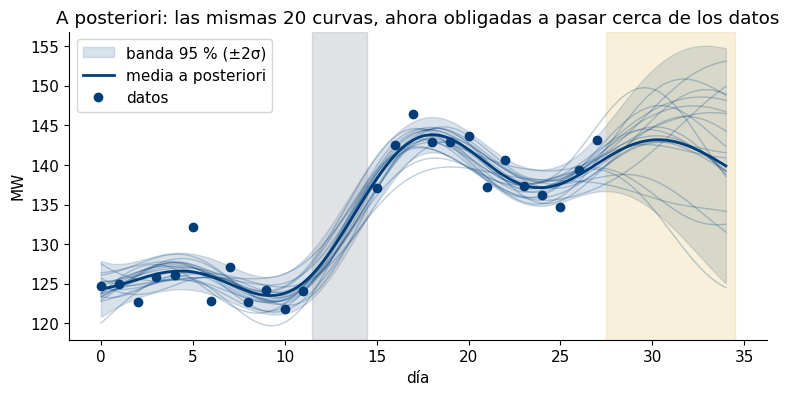

In [7]:
plt.plot(x, spost, color=AZUL, alpha=0.25, lw=1)
plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.15, label="banda 95 % (±2σ)")
plt.plot(x, mpost, color=AZUL, lw=2, label="media a posteriori")
plt.plot(X, Y, "o", color=AZUL, label="datos")
plt.axvspan(27.5, 34.5, color=ORO, alpha=0.15); plt.axvspan(11.5, 14.5, color=GRIS, alpha=0.25)
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left")
plt.title("A posteriori: las mismas 20 curvas, ahora obligadas a pasar cerca de los datos")
plt.show()

Mira tres cosas:

1. Donde hay datos, la banda es angosta: los datos **compraron** certeza.
2. En el hueco del medidor la banda se abre un poco, y se vuelve a cerrar: el GP **interpola** con honestidad.
3. Hacia la próxima semana la banda se abre cada día más: el GP **sabe que no sabe**.

🟡 **Tu turno.** Sube `sigma_n` a 10 (medidor malo), vuelve a correr desde la sección 2 y observa la banda sobre los datos. Regresa a 2.5.

## 5. La respuesta a la pregunta

*¿Cuánta capacidad reservar la próxima semana?* La banda superior del 95 % nos da un número defendible.

In [8]:
futuro = x >= 28
pico_esperado = mpost[futuro].max()
capacidad_95  = (mpost + 2*stdpo)[futuro].max()
print(f"Pico esperado la próxima semana : {pico_esperado:6.1f} MW")
print(f"Capacidad a reservar (95 %)     : {capacidad_95:6.1f} MW")
print(f"Margen que compra la incertidumbre: {capacidad_95 - pico_esperado:4.1f} MW")

Pico esperado la próxima semana :  143.2 MW
Capacidad a reservar (95 %)     :  155.0 MW
Margen que compra la incertidumbre: 11.9 MW


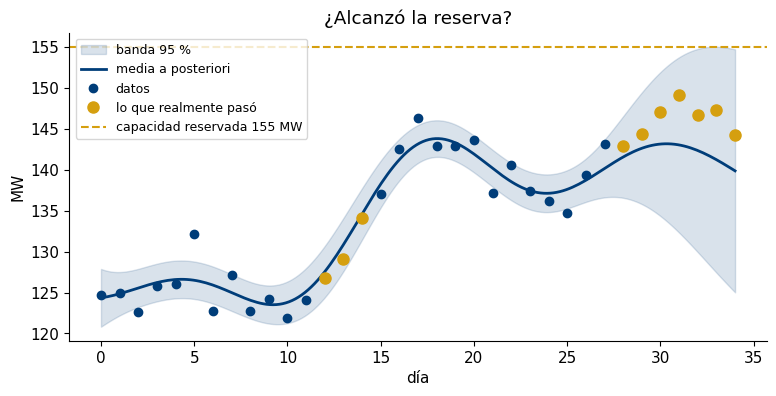

Días ocultos dentro de la banda: 10 de 10


In [9]:
# Ahora sí: destapamos la semana que estaba escondida
plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.15, label="banda 95 %")
plt.plot(x, mpost, color=AZUL, lw=2, label="media a posteriori")
plt.plot(X, Y, "o", color=AZUL, label="datos")
plt.plot(t[~observado], y[~observado], "o", color=ORO, markersize=8, label="lo que realmente pasó")
plt.axhline(capacidad_95, color=ORO, ls="--", label=f"capacidad reservada {capacidad_95:.0f} MW")
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left", fontsize=9)
plt.title("¿Alcanzó la reserva?")
plt.show()

dentro = np.abs(y[~observado] - np.interp(t[~observado], x, mpost)) <= 2*np.interp(t[~observado], x, stdpo)
print(f"Días ocultos dentro de la banda: {dentro.sum()} de {dentro.size}")

🟡 **Tu turno.** Compara con el número que anotaste al principio. ¿Te quedaste corto o te pasaste? ¿Qué te dio el GP que tu ojo no?

## 6. Lo mismo con scikit-learn, en 3 líneas

Todo lo anterior ya está programado (y probado por miles de personas) en `scikit-learn`.
Le damos el **mismo kernel** con los **mismos hiperparámetros** y le pedimos que no los cambie (`optimizer=None`).

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

kernel = ConstantKernel(sigma_f**2, "fixed") * RBF(length_scale=ell, length_scale_bounds="fixed")
gp = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, optimizer=None)   # alpha = varianza del ruido
gp.fit(X[:, None], Y - b)                                        # scikit espera columnas: X[:, None]; restamos la media b
m_skl, s_skl = gp.predict(x[:, None], return_std=True)
m_skl = m_skl + b                                                # devolvemos la media

print("scikit-learn listo")

scikit-learn listo


## 7. Demostración: las dos rutas dan lo mismo

Máxima diferencia en la media      : 2.84e-14 MW
Máxima diferencia en la desviación : 2.75e-14 MW


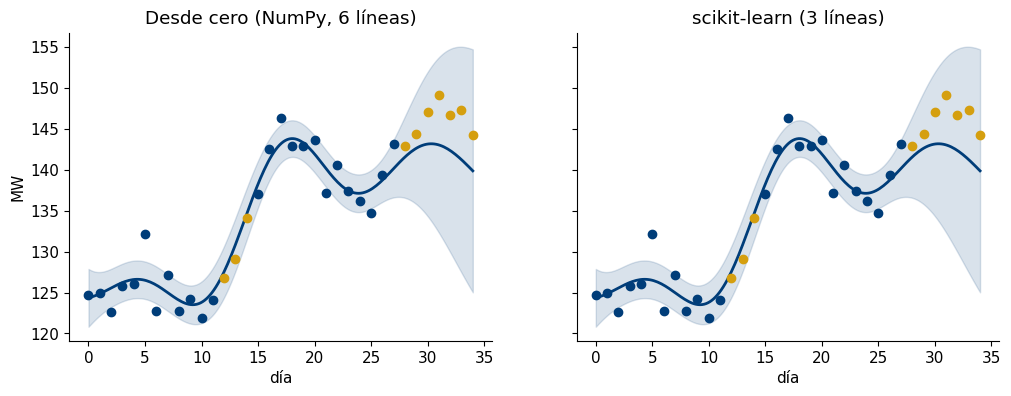

In [11]:
print(f"Máxima diferencia en la media      : {np.abs(mpost - m_skl).max():.2e} MW")
print(f"Máxima diferencia en la desviación : {np.abs(stdpo - s_skl).max():.2e} MW")

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a_, mm, ss, titulo in [(ax[0], mpost, stdpo, "Desde cero (NumPy, 6 líneas)"), (ax[1], m_skl, s_skl, "scikit-learn (3 líneas)")]:
    a_.fill_between(x, mm - 2*ss, mm + 2*ss, color=AZUL, alpha=0.15)
    a_.plot(x, mm, color=AZUL, lw=2); a_.plot(X, Y, "o", color=AZUL)
    a_.plot(t[~observado], y[~observado], "o", color=ORO)
    a_.set_title(titulo); a_.set_xlabel("día")
ax[0].set_ylabel("MW")
plt.show()

Diferencias del orden de $10^{-13}$: es el mismo cálculo, con el mismo álgebra. La ventaja de scikit-learn no es que sea "mejor",
es que **puede aprender los hiperparámetros solo** (maximiza la verosimilitud marginal). Veámoslo:

Kernel que aprendió scikit-learn: 8.32**2 * RBF(length_scale=4.15)
   ℓ a mano = 5.0 días   →   ℓ aprendido = 4.15 días
   Capacidad 95 % a mano = 155.0 MW   →   con ℓ aprendido = 154.5 MW


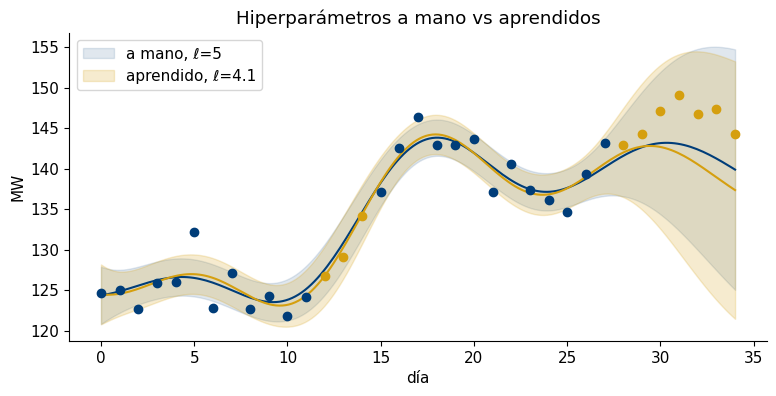

In [12]:
kernel_libre = ConstantKernel(sigma_f**2) * RBF(length_scale=ell)       # sin "fixed": se pueden ajustar
gp_libre = GaussianProcessRegressor(kernel=kernel_libre, alpha=sigma_n**2, n_restarts_optimizer=5, random_state=0)
gp_libre.fit(X[:, None], Y - b)
m_lib, s_lib = gp_libre.predict(x[:, None], return_std=True); m_lib += b

print("Kernel que aprendió scikit-learn:", gp_libre.kernel_)
print(f"   ℓ a mano = {ell:.1f} días   →   ℓ aprendido = {gp_libre.kernel_.k2.length_scale:.2f} días")
print(f"   Capacidad 95 % a mano = {capacidad_95:.1f} MW   →   con ℓ aprendido = {(m_lib + 2*s_lib)[futuro].max():.1f} MW")

plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.12, label=f"a mano, ℓ={ell:.0f}")
plt.fill_between(x, m_lib - 2*s_lib, m_lib + 2*s_lib, color=ORO, alpha=0.2, label=f"aprendido, ℓ={gp_libre.kernel_.k2.length_scale:.1f}")
plt.plot(x, mpost, color=AZUL); plt.plot(x, m_lib, color=ORO)
plt.plot(X, Y, "o", color=AZUL); plt.plot(t[~observado], y[~observado], "o", color=ORO)
plt.xlabel("día"); plt.ylabel("MW"); plt.legend(loc="upper left"); plt.title("Hiperparámetros a mano vs aprendidos")
plt.show()

## 8. Lo que aprendimos y lo que queda de tarea

**Un proceso gaussiano es:** un kernel (la hipótesis de parecido) + seis líneas de álgebra que actualizan esa hipótesis con los datos.
Devuelve una curva **y** su margen de error, y el margen es la respuesta a preguntas de planeación ("¿cuánto reservo?").

| | Desde cero | scikit-learn |
|---|---|---|
| Líneas | ~15 | 3 |
| Entiendes qué pasa | sí | solo si hiciste lo anterior |
| Aprende hiperparámetros | no (a mano) | sí |
| Resultado | idéntico | idéntico |

**Tarea** (`03_tarea.ipynb`): la misma ciudad, pero ahora con su **ritmo semanal** (los fines de semana baja la demanda).
Verás que un solo kernel RBF ya no alcanza, y añadirás un segundo kernel **periódico**. Los kernels se suman.

---
### Apéndice (opcional): la versión literal del código MATLAB

El código de la presentación no escribe el kernel directo; lo construye con **1000 "campanas"** $\phi$ centradas en una malla,
y define $k = \phi \, \Sigma \, \phi^\top$. Es la *vista de características* del mismo GP. Aquí está traducido línea por línea
para que compruebes que da la misma banda (con una escala de $\ell$ ligeramente distinta, porque sumar campanas ensancha la campana resultante).

Diferencia con la versión directa — media: 0.031 MW, desviación: 0.103 MW


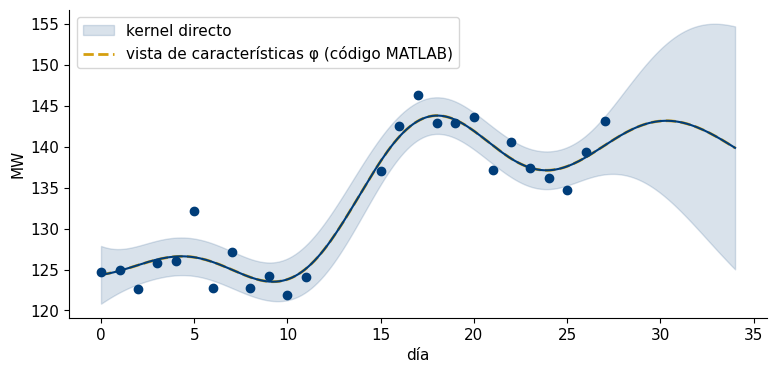

In [13]:
# --- traducción literal de la lámina (vista de características φ) ---
F = 1000
centros = np.linspace(-5, 39, F)
ell_phi = ell / np.sqrt(2)                                          # sumar campanas de ancho ℓ/√2 da un kernel de ancho ℓ
phi = lambda a: np.exp(-0.5 * (a[:, None] - centros[None, :])**2 / ell_phi**2)     # phi = @(a)(exp(-0.5*bsxfun(@minus,a,linspace(...)).^2./ell.^2))
mu = np.zeros(F)                                                    # mu = zeros(F,1)
escala = sigma_f**2 / (phi(np.array([17.0])) @ phi(np.array([17.0])).T)[0, 0]
Sigma = escala * np.eye(F)                                          # Sigma = eye(F)  (escalada para que k(t,t) = σ_f²)

phix = phi(x);  phiX = phi(X)
kxx_phi = phix @ Sigma @ phix.T                                     # kxx = phix*Sigma*phix'
kXX_phi = phiX @ Sigma @ phiX.T                                     # kXX = phiX*Sigma*phiX'
B1_ = phix @ mu + b;  B2_ = phix @ Sigma @ phiX.T;  B3_ = kXX_phi + sigma_n**2 * np.eye(N)
R_  = np.linalg.cholesky(B3_).T;  B4_ = Y - (phiX @ mu + b)
A_  = np.linalg.solve(R_.T, B2_.T).T
mpost_phi = B1_ + A_ @ np.linalg.solve(R_.T, B4_)
stdpo_phi = np.sqrt(np.clip(np.diag(kxx_phi - A_ @ A_.T), 0, None))

print(f"Diferencia con la versión directa — media: {np.abs(mpost_phi - mpost).max():.3f} MW, desviación: {np.abs(stdpo_phi - stdpo).max():.3f} MW")
plt.fill_between(x, mpost - 2*stdpo, mpost + 2*stdpo, color=AZUL, alpha=0.15, label="kernel directo")
plt.plot(x, mpost_phi, color=ORO, lw=2, ls="--", label="vista de características φ (código MATLAB)")
plt.plot(x, mpost, color=AZUL); plt.plot(X, Y, "o", color=AZUL)
plt.legend(loc="upper left"); plt.xlabel("día"); plt.ylabel("MW"); plt.show()